In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as tcr
import seaborn as sns

#Set a default seaborn style
sns.set_style('whitegrid')

In [2]:
#data import
data = pd.read_csv('/home/amybirdee/hobby_projects/attachment_style_prediction/attachment_survey_with_text.csv',)

In [3]:
#review data
data.head()

,__row_id,age,gender,relationship_status,parenting_style,conflict_response,comfort_with_intimacy,fear_of_abandonment,trust_in_others,openness_in_relationships,social_support_perception,relationship_satisfaction,mental_health_status,attachment_style_label,relationship_reflection
0,0,45,Male,Single,Authoritative,Compromising,3,1,2,5,5,5,Stable,Dismissive,I am single by choice these days and oddly con...
1,1,31,Female,In a relationship,Authoritative,Passive,2,2,4,1,1,5,Mild Issues,Fearful,Being in a steady relationship feels safe and ...
2,2,24,Prefer not to say,In a relationship,Permissive,Compromising,4,1,4,1,4,4,Stable,Secure,I am comfortable being close and enjoy the eas...
3,3,37,Male,Single,NaN,Avoidant,1,5,1,2,5,3,Mild Issues,Fearful,I find myself catching between wanting connect...
4,4,35,Female,In a relationship,Permissive,Assertive,3,1,5,2,2,5,Mild Issues,Secure,I feel lucky in my partnership and approach di...


# Data Exploration and Preprocessing

In [4]:
#check shape of dataframe - 15 columns, 3000 rows
data.shape

(3000, 15)

In [5]:
#check datatypes - some null values in parenting style (perhaps non-parents)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 15 columns):
__row_id                     3000 non-null int64
age                          3000 non-null int64
gender                       3000 non-null object
relationship_status          3000 non-null object
parenting_style              2415 non-null object
conflict_response            3000 non-null object
comfort_with_intimacy        3000 non-null int64
fear_of_abandonment          3000 non-null int64
trust_in_others              3000 non-null int64
openness_in_relationships    3000 non-null int64
social_support_perception    3000 non-null int64
relationship_satisfaction    3000 non-null int64
mental_health_status         3000 non-null object
attachment_style_label       3000 non-null object
relationship_reflection      3000 non-null object
dtypes: int64(8), object(7)
memory usage: 351.6+ KB


In [6]:
#check data summary -ages range from 17-50, scales from 1-5
data.describe()

,__row_id,age,comfort_with_intimacy,fear_of_abandonment,trust_in_others,openness_in_relationships,social_support_perception,relationship_satisfaction
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1499.500000,33.744333,2.960667,3.035000,3.068333,3.062333,3.027667,3.012667
std,866.169729,9.830828,1.417906,1.411302,1.416921,1.435433,1.400079,1.424494
min,0.000000,17.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,749.750000,25.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
50%,1499.500000,34.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
75%,2249.250000,42.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
max,2999.000000,50.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [7]:
#check value counts of target variable - mainly avoidants
target_counts = data['attachment_style_label'].value_counts()
target_counts

Fearful        930
Preoccupied    814
Dismissive     669
Secure         587
Name: attachment_style_label, dtype: int64

In [8]:
#rename target values
data['attachment_style_label'] = data['attachment_style_label'].str.replace('Fearful', 'Fearful Avoidant').\
str.replace('Preoccupied', 'Anxious').str.replace('Dismissive', 'Dismissive Avoidant')

In [9]:
#save this version of the dataframe as these are the labels we will use for modelling
data_updated_labels = data.to_csv('/home/amybirdee/hobby_projects/attachment_style_prediction/attachment_survey_with_labels.csv')

# Data Visualisation

In [10]:
#create a new version of the dataframe containing the features we will visualise - we won't visualise age
#since there this will likely look messy and we will convert the likert scale fields into text fields
#for easier visual understanding

chart_data = data.drop(['__row_id', 'age', 'relationship_reflection'], axis = 1)

chart_data['comfort_with_intimacy'] = chart_data['comfort_with_intimacy'].replace({1: 'Low Comfort', 
                                                                                   2: 'Low Comfort',
                                                                                   3: 'Neutral',
                                                                                   4: 'High Comfort',
                                                                                   5: 'High Comfort'})

chart_data['fear_of_abandonment'] = chart_data['fear_of_abandonment'].replace({1: 'Not Fearful', 
                                                                               2: 'Not Fearful',
                                                                               3: 'Neutral',
                                                                               4: 'Fearful',
                                                                               5: 'Fearful'})

chart_data['trust_in_others'] = chart_data['trust_in_others'].replace({1: 'Low Trust', 
                                                                       2: 'Low Trust',
                                                                       3: 'Neutral',
                                                                       4: 'High Trust',
                                                                       5: 'High Trust'})

chart_data['openness_in_relationships'] = chart_data['openness_in_relationships'].replace({1: 'Closed', 
                                                                                           2: 'Closed',
                                                                                           3: 'Neutral',
                                                                                           4: 'Open',
                                                                                           5: 'Open'})

chart_data['social_support_perception'] = chart_data['social_support_perception'].replace({1: 'Low Support', 
                                                                                           2: 'Low Support',
                                                                                           3: 'Neutral',
                                                                                           4: 'High Support',
                                                                                           5: 'High Support'})

chart_data['relationship_satisfaction'] = chart_data['relationship_satisfaction'].replace({1: 'Low Satisfaction', 
                                                                                           2: 'Low Satisfaction',
                                                                                           3: 'Neutral',
                                                                                           4: 'High Satisfaction',
                                                                                           5: 'High Satisfaction'})

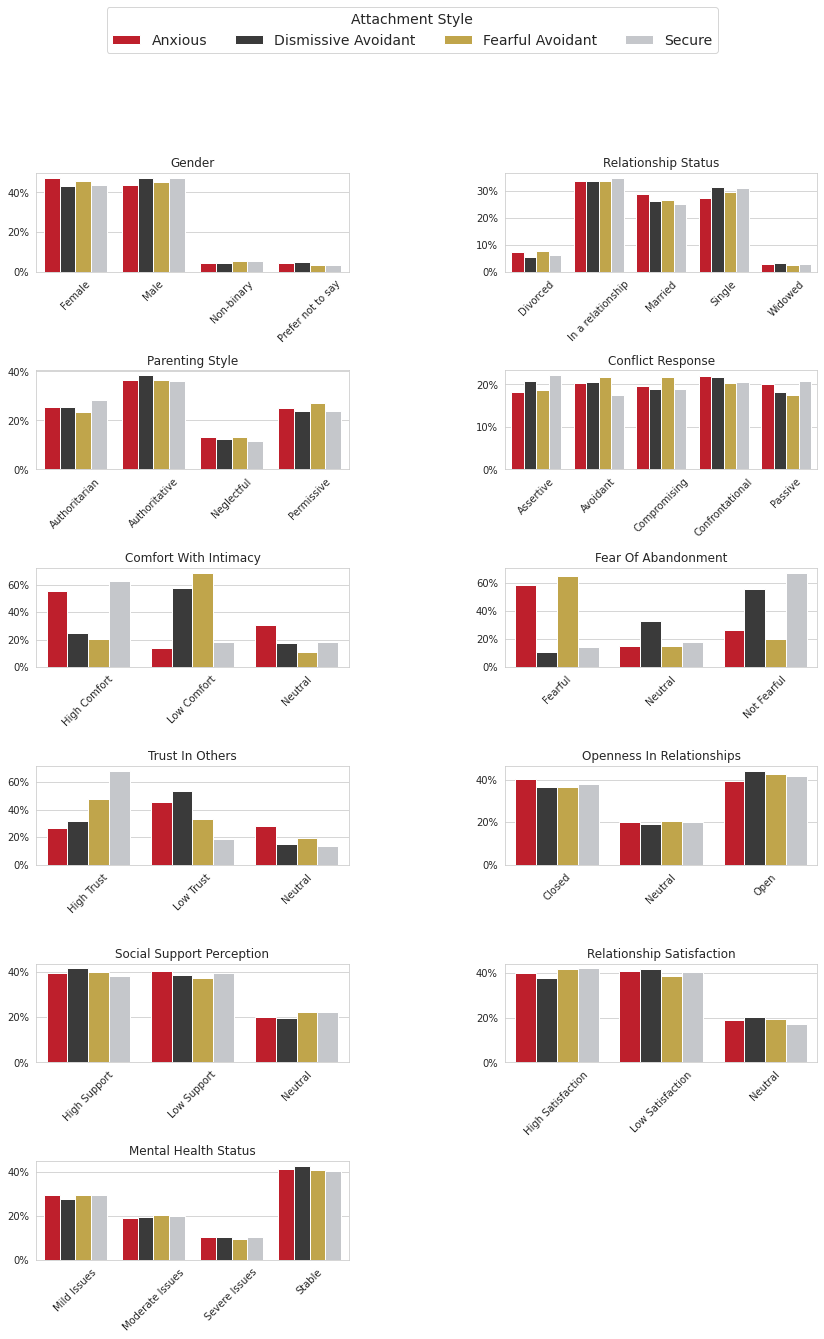

In [15]:
#we will create multiple charts which show each feature and the target

#only need the features for the chart, not the target
feature_cols = [col for col in chart_data.columns if col != 'attachment_style_label']

#create a dictionary to store the dataframes
chart_data_dict = {}

#creating a figure for the charts
fig = plt.figure(figsize = (14, 20))

sns.set_palette(sns.color_palette(['#D90416', '#3A3A3A', '#D4AF37', '#C4C7CC'])) 

#store legend info
handles, labels = None, None

#looping through chart data to make charts
for i, column in enumerate(feature_cols, start = 1):
    #group data
    chart_data_dict[column] = chart_data.groupby([column, 'attachment_style_label']).size().reset_index()\
    .rename(columns = {0: 'Count', 'attachment_style_label': 'Attachment Style'})
    
    #normalise data within each attachment style
    chart_data_dict[column]['Proportion'] = (chart_data_dict[column].groupby('Attachment Style')['Count']\
    .transform(lambda x: x / x.sum())) * 100
    
    #create charts
    ax = plt.subplot(6, 2, i)
    sns.barplot(x = column, y = 'Proportion', data = chart_data_dict[column], hue = 'Attachment Style')
    
    #capture legend handles once
    if handles is None:
        handles, labels = ax.get_legend_handles_labels()
    
    #applying formatting
    ax.yaxis.set_major_formatter(tcr.PercentFormatter(xmax = 100, decimals = 0))
    plt.xticks(rotation = 45)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title(column.replace('_', ' ').title())
    
    #remove legend from individual subplot
    ax.get_legend().remove()
    
#add one global legend
fig.legend(handles, labels, loc = 'upper center', ncol = 4, fontsize = 14, title = 'Attachment Style',
          title_fontsize = 14)

#adjusting space between subplots
plt.subplots_adjust(wspace = 0.5, hspace = 1.0)




# Key Insights

**The dataset is skewed towards avoidant attachment styles, which may introduce bias in downstream modelling and affect predictive performance across minority classes**

**Gender does not appear to significantly correlate with attachment style, with similar distributions observed across male and female groups**

**Secure individuals display a consistently positive relational profile across features, with high trust and comfort with intimacy along with low fear of abandonment**

**Anxious and fearful avoidant types both exhibit high fear of abandonment, but differ in relational behaviour. Anxious individuals are comfortable with intimacy despite low trust, indicating a dependency on closeness even in the absence of relational security. Fearful avoidants have high fear and a low intimacy comfort reflecting internal conflict between a desire for connection and discomfort with closeness**

**Dismissive avoidants demonstrate low trust, low fear of abandonment and a low comfort with intimacy, suggesting a more self-reliant and emotionally distant relational style**

**Neutral responses appear across all attachment styles, potentially diluting signal and masking more extreme behavioural tendencies**

**Strong separation across features such as trust, intimacy comfort, and fear of abandonment suggests these variables are likely to be key predictors in modelling attachment style**